In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import scipy.optimize as opt
# Cargar datos
gal_0 = pd.read_csv('/mnt/sda2/extragalactica/2_practico/pr2_shulypuddu.csv')
head= 'ra,dec,z,c_par,fracDeV_r,velDisp,abs_model_mag_u,abs_model_mag_g,abs_model_mag_r,abs_model_mag_i,abs_model_mag_z,abs_petro_mag_u,abs_petro_mag_g,abs_petro_mag_r,abs_petro_mag_i,abs_petro_mag_z,color_u_r,color_g_r,mu_sup,petroR50_r,petroR90_r'
df0 = pd.read_csv('/mnt/sda2/extragalactica/2_practico/galaxias_finales.csv', names=head.split(','), skiprows=1)
bar_color="#7166D1"
edge_color= "#695ED1"
linea_color='tomato'

galaxias_brillante = df0[df0['abs_model_mag_r'] > -15]
#esta galaxia no se xq quedo tan FEA, asique la filtro
df = df0[df0['abs_model_mag_r'] < -15]
tempranas = df[df['c_par'] >= 2.5]
tardias = df[df['c_par'] < 2.5]

bulge = df[df['fracDeV_r'] >= 0.8]
disco = df[df['fracDeV_r']<= 0.2]


In [12]:
df.head()

,ra,dec,z,c_par,fracDeV_r,velDisp,abs_model_mag_u,abs_model_mag_g,abs_model_mag_r,abs_model_mag_i,...,abs_petro_mag_u,abs_petro_mag_g,abs_petro_mag_r,abs_petro_mag_i,abs_petro_mag_z,color_u_r,color_g_r,mu_sup,petroR50_r,petroR90_r
0,248.427338,40.153099,0.029141,3.313087,1.000000,120.217003,-18.081985,-19.792364,-20.566236,-20.911688,...,-18.114418,-19.751654,-20.515257,-20.859497,-21.099255,2.484251,0.773872,19.543352,1.816034,6.016678
1,246.718796,40.970314,0.029176,2.386080,0.430332,23.562990,-17.193432,-18.272331,-18.607775,-18.798756,...,-16.602791,-17.723532,-17.989046,-17.940647,-18.180756,1.414343,0.335443,22.887016,2.654387,6.333578
2,179.244446,61.456379,0.042445,2.556281,0.000000,42.245541,-18.178293,-19.584330,-20.246607,-20.587896,...,-18.299414,-19.633509,-20.228508,-20.469255,-20.720722,2.068314,0.662277,21.683024,4.068568,10.400403
3,246.704376,42.678925,0.030449,2.392693,0.385215,74.192261,-17.313629,-18.892509,-19.668669,-20.021475,...,-17.116110,-18.930010,-19.740999,-20.029165,-20.327076,2.355040,0.776159,21.168137,2.675173,6.400869
4,239.459000,48.609646,0.020696,1.802537,0.000000,0.000000,-16.646736,-17.962826,-18.573967,-18.822937,...,-16.573187,-17.829836,-18.475717,-18.679157,-18.886627,1.927231,0.611141,22.258551,2.489359,4.487163


In [2]:
ra = gal_0['ra']
dec = gal_0['dec']
z = gal_0['z']
r_corregido= gal_0['petroMag_r']-gal_0['extinction_r']


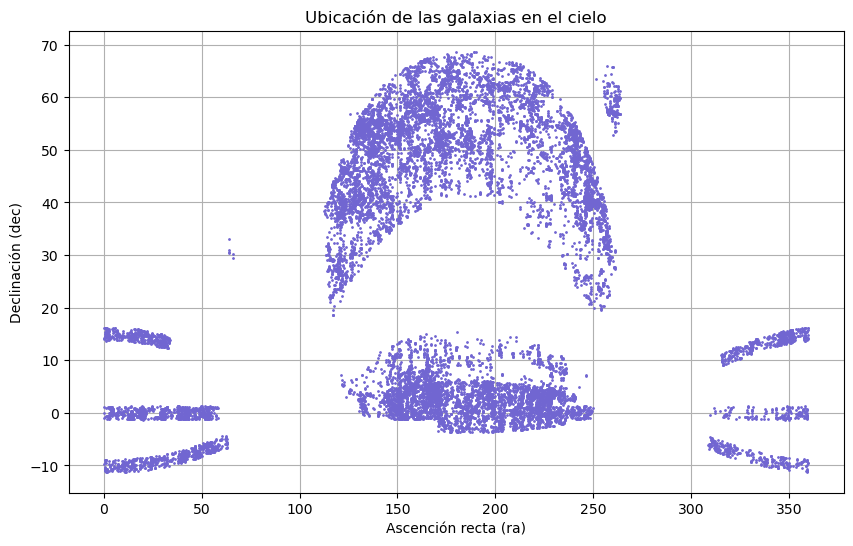

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(ra, dec, 'o', markersize=1, color=bar_color)
plt.xlabel("Ascención recta (ra)")
plt.ylabel("Declinación (dec)")
plt.title("Ubicación de las galaxias en el cielo")
plt.grid(True)
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/gal_in_sky.png', dpi=300,bbox_inches='tight')

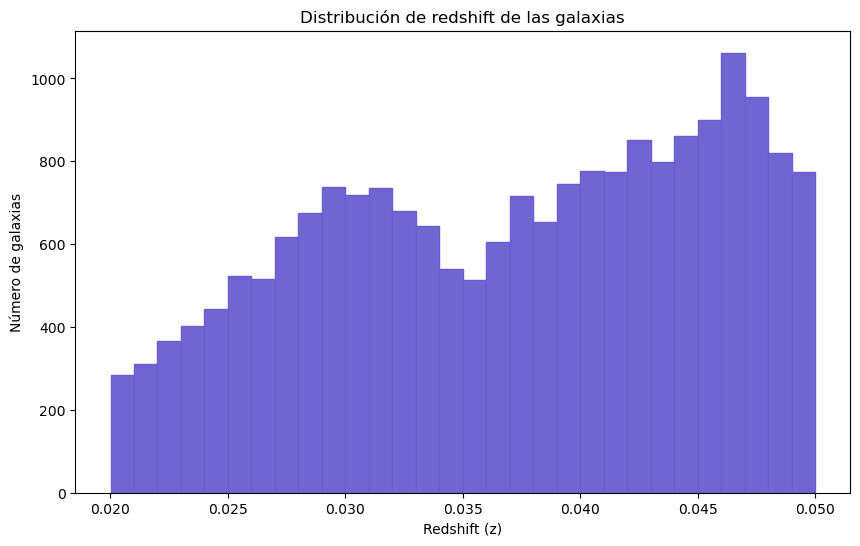

In [4]:
plt.figure(figsize=(10,6))
plt.hist(z, bins=30, edgecolor=edge_color,facecolor=bar_color)
plt.xlabel("Redshift (z)")
plt.ylabel("Número de galaxias")
plt.title("Distribución de redshift de las galaxias")
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/gal_z.png', dpi=300,bbox_inches='tight')


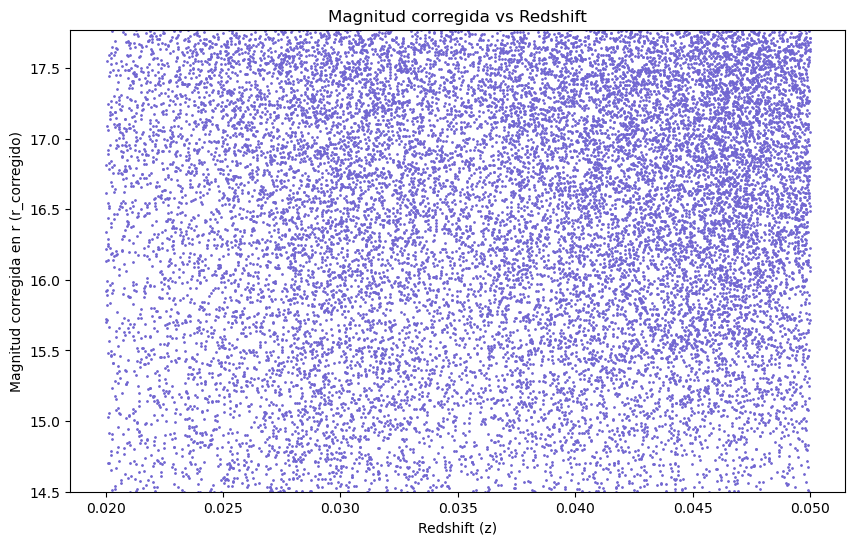

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(z, r_corregido, s=1, color=bar_color)
plt.ylim(14.5,17.77)
plt.xlabel("Redshift (z)")
plt.ylabel("Magnitud corregida en r (r_corregido)")
plt.title("Magnitud corregida vs Redshift")
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/mag_vs_z.png', dpi=300,bbox_inches='tight')

In [10]:
color_u_r = df['color_u_r'].dropna()

# Definir la función suma de dos gaussianas
def doble_gaussiana(x, amp1, mu1, sigma1, amp2, mu2, sigma2):
    return (amp1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) +
            amp2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)))

def gauss(x,amp,mu,sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Obtener histograma (cuentas y bordes)

cuentas, bordes = np.histogram(color_u_r, bins=1000,density=True)
centros = (bordes[:-1] + bordes[1:]) / 2

# Estimaciones iniciales para los parámetros
p0 = [1, color_u_r.mean()-0.5, color_u_r.std()/2, 1, color_u_r.mean()+0.5, color_u_r.std()/2]

# Ajuste
params, cov = opt.curve_fit(doble_gaussiana, centros, cuentas, p0=p0)

x_fit = np.linspace(color_u_r.min(), color_u_r.max(), 200)
x1_fit = np.linspace(color_u_r.min(), 3, 200)
x2_fit = np.linspace( 1,color_u_r.max(), 200)
g_azul= gauss(x1_fit,params[0],params[1],params[2])
g_rojo= gauss(x2_fit,params[3],params[4],params[5])

def diferencia(x):
    return gauss(x,params[0],params[1],params[2]) - gauss(x,params[3],params[4],params[5])
x_inicial= (params[4]+params[1])/2
x_cruce = opt.fsolve(diferencia, x_inicial)[0]

rojo = df[df['color_u_r'] > x_cruce]
azul = df[df['color_u_r'] < x_cruce]


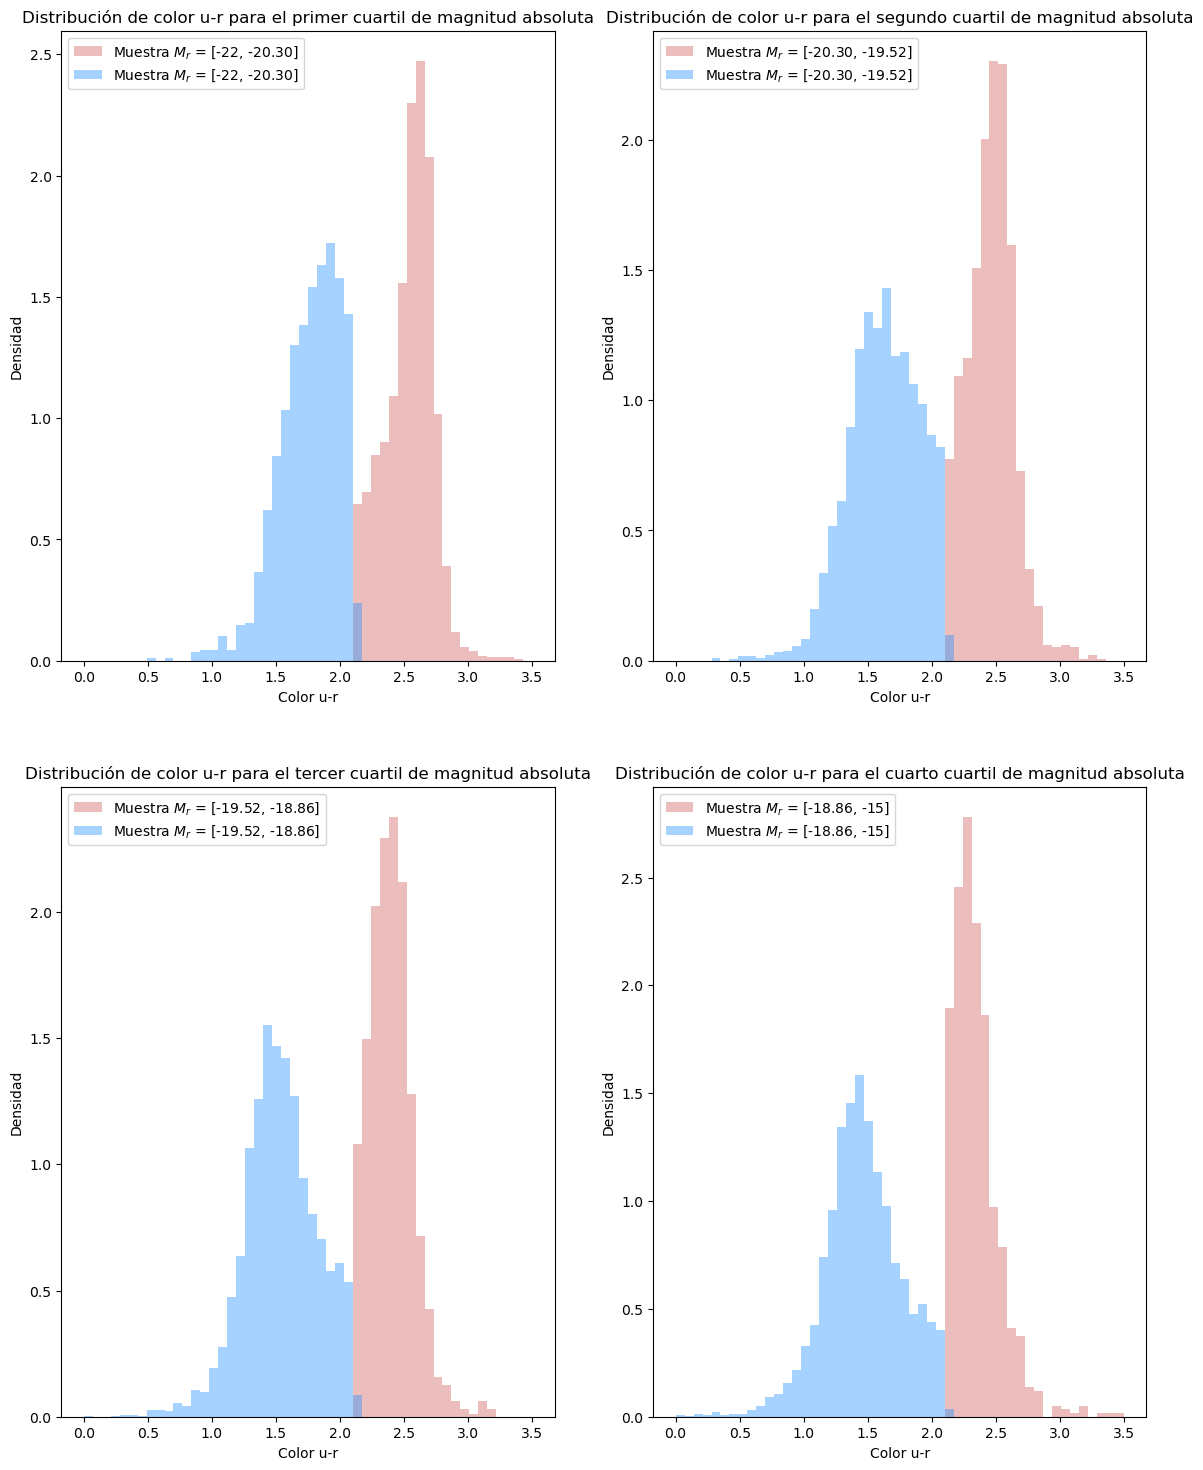

In [ ]:
m_25=np.percentile(df['abs_petro_mag_r'],25)
mask_25=df['abs_petro_mag_r']<=m_25
m_50=np.percentile(df['abs_petro_mag_r'],50)
mask_50=(df['abs_petro_mag_r']<=m_50) & (df['abs_petro_mag_r']>m_25)
m_75=np.percentile(df['abs_petro_mag_r'],75)
mask_75=(df['abs_petro_mag_r']<=m_75) & (df['abs_petro_mag_r']>m_50)
mask_100=df['abs_petro_mag_r']>m_75
bin=50
fig, axs = plt.subplots(2, 2, figsize=(14, 18)) # 2 filas, 2 columnas

axs[0, 0].hist(rojo['color_u_r'][mask_25],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Muestra $M_r$ = [-22, {m_25:.2f}]')
axs[0, 0].hist(azul['color_u_r'][mask_25],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Muestra $M_r$ = [-22, {m_25:.2f}]')
axs[0, 0].set_title('Distribución de color u-r para el primer cuartil de magnitud absoluta')
axs[0, 0].set_xlabel('Color u-r')
axs[0, 0].set_ylabel('Densidad')
axs[0, 0].legend()
axs[0, 1].hist(rojo['color_u_r'][mask_50],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Muestra $M_r$ = [{m_25:.2f}, {m_50:.2f}]')
axs[0, 1].hist(azul['color_u_r'][mask_50],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Muestra $M_r$ = [{m_25:.2f}, {m_50:.2f}]')
axs[0, 1].set_title('Distribución de color u-r para el segundo cuartil de magnitud absoluta')
axs[0, 1].set_xlabel('Color u-r')
axs[0, 1].set_ylabel('Densidad')
axs[0, 1].legend()
axs[1, 0].hist(rojo['color_u_r'][mask_75],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Muestra $M_r$ = [{m_50:.2f}, {m_75:.2f}]')
axs[1, 0].hist(azul['color_u_r'][mask_75],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Muestra $M_r$ = [{m_50:.2f}, {m_75:.2f}]')
axs[1, 0].set_title('Distribución de color u-r para el tercer cuartil de magnitud absoluta')
axs[1, 0].set_xlabel('Color u-r')
axs[1, 0].set_ylabel('Densidad')
axs[1, 0].legend()
axs[1, 1].hist(rojo['color_u_r'][mask_100],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Muestra $M_r$ = [{m_75:.2f}, -15]')
axs[1, 1].hist(azul['color_u_r'][mask_100],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Muestra $M_r$ = [{m_75:.2f}, -15]')
axs[1, 1].set_title('Distribución de color u-r para el cuarto cuartil de magnitud absoluta')
axs[1, 1].set_xlabel('Color u-r')
axs[1, 1].set_ylabel('Densidad')
axs[1, 1].legend()
